In [ ]:
!pip install --quiet xgboost
!pip install --quiet eli5
!pip install --quiet shap
!pip install --quiet lime
!pip install --quiet dice-ml
!pip install scikit-learn==1.2.2
!pip install --quiet --upgrade eli5

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

import sklearn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


import shap
import eli5
from eli5.sklearn import PermutationImportance
from sklearn.inspection import PartialDependenceDisplay
import lime
import lime.lime_tabular
import dice_ml

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Set Prameters for Reproduciblity
pd.set_option("display.max_rows",100)

TARGET = "ObesityRisk"
n_splits = 10
RANDOM_SEED = 7

# load dataset
data_df = pd.read_csv("obesity_dataset.csv")

In [ ]:
# Update the name of columns to make it more understandable

# Define the new column names
new_column_names = {'FAVC': 'highcal_intake',
                    'FCVC': 'veg_intake',
                    'NCP': 'meals_daily',
                    'CAEC': 'snacking',
                    'CH2O': 'water_intake_daily',
                    'SCC': 'track_cal_intake',
                    'FAF': 'physical_weekly',
                    'TUE': 'tech_usage_daily',
                    'CALC': 'alcohol_intake',
                    'MTRANS': 'transport_mode'
                   }

# Rename the columns using the rename() method
data_df.rename(columns=new_column_names, inplace=True)

In [ ]:
# View dataframe
print(f"Total number of rows: {len(data_df)}")
print(f"Total number of columns: {data_df.shape[1]}\n")

data_df.head(10)

Total number of rows: 15327
Total number of columns: 19



,id,Gender,Age,Height,Weight,family_history_with_overweight,highcal_intake,veg_intake,meals_daily,snacking,SMOKE,water_intake_daily,track_cal_intake,physical_weekly,tech_usage_daily,alcohol_intake,transport_mode,BMI,ObesityRisk
0,4678,Male,25.00,1.80,73.00,yes,yes,Sometimes,3 meals,Frequently,no,1-2 litres,no,more than 4 days,3-5 hours,Sometimes,Walking,22.53,Normal_Weight
1,13120,Female,20.00,1.52,42.00,no,no,Always,1-2 meals,Frequently,no,less than 1 litre,no,0 days,0-2 hours,Sometimes,Public_Transportation,18.18,Underweight
2,14288,Female,26.00,1.61,111.94,yes,yes,Always,3 meals,Sometimes,no,more than 2 litres,no,0 days,0-2 hours,Sometimes,Public_Transportation,43.11,Obesity_Severe
3,3740,Female,21.62,1.74,133.47,yes,yes,Always,3 meals,Sometimes,no,more than 2 litres,no,2-4 days,3-5 hours,Sometimes,Public_Transportation,44.14,Obesity_Severe
4,4919,Male,18.42,1.75,52.00,yes,yes,Never,3 meals,Sometimes,no,1-2 litres,no,1-2 days,3-5 hours,no,Public_Transportation,16.91,Underweight
5,6054,Male,17.00,1.77,97.42,yes,yes,Sometimes,3 meals,Sometimes,no,1-2 litres,no,more than 4 days,3-5 hours,no,Public_Transportation,30.97,Obesity
6,7136,Female,21.00,1.56,49.00,no,yes,Sometimes,3 meals,Sometimes,no,less than 1 litre,no,0 days,0-2 hours,Sometimes,Public_Transportation,20.13,Normal_Weight
7,3062,Male,19.00,1.75,86.00,yes,yes,Always,more than 3 meals,Always,no,1-2 litres,no,2-4 days,0-2 hours,Sometimes,Public_Transportation,28.08,Overweight
8,1298,Male,30.96,1.75,120.10,yes,yes,Sometimes,3 meals,Sometimes,no,more than 2 litres,no,1-2 days,0-2 hours,Sometimes,Public_Transportation,39.22,Obesity_Severe
9,8182,Female,18.00,1.65,84.49,yes,yes,Sometimes,3 meals,Sometimes,no,less than 1 litre,no,1-2 days,0-2 hours,no,Public_Transportation,31.04,Obesity


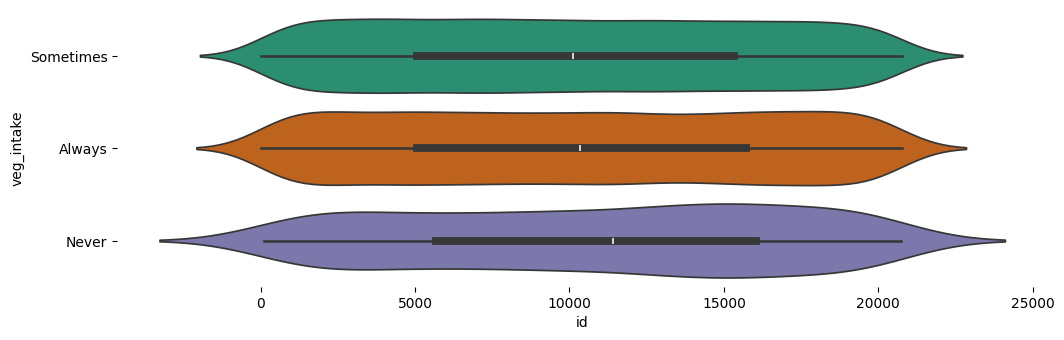

In [ ]:
# @title veg_intake vs id

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(data_df['veg_intake'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(data_df, x='id', y='veg_intake', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
data_df.describe()

,id,Age,Height,Weight,BMI
count,15327.00,15327.00,15327.00,15327.00,15327.00
mean,10296.64,23.28,1.69,81.53,28.23
std,6004.51,5.78,0.09,25.33,8.01
min,0.00,14.00,1.45,39.00,12.87
25%,5073.50,19.00,1.63,60.00,21.74
50%,10235.00,21.84,1.70,80.00,27.43
75%,15518.50,25.95,1.76,104.57,33.90
max,20756.00,61.00,1.98,165.06,54.99


In [ ]:
# Check counts, column dtypes, null and unique count in each Column

tmp = pd.DataFrame(index=data_df.columns)
tmp['count'] = data_df.count()
tmp['dtype'] = data_df.dtypes
tmp['nunique'] = data_df.nunique()
tmp['%nunique'] = (tmp['nunique']/len(data_df))*100
tmp['%null'] = (data_df.isnull().sum()/len(data_df))*100

tmp = tmp.round(3)

display(tmp)
del tmp

,count,dtype,nunique,%nunique,%null
id,15327,int64,15327,100.00,0.00
Gender,15327,object,2,0.01,0.00
Age,15327,float64,1555,10.14,0.00
Height,15327,float64,1715,11.19,0.00
Weight,15327,float64,1800,11.74,0.00
family_history_with_overweight,15327,object,2,0.01,0.00
highcal_intake,15327,object,2,0.01,0.00
veg_intake,15327,object,3,0.02,0.00
meals_daily,15327,object,3,0.02,0.00
snacking,15327,object,4,0.03,0.00


In [ ]:
# Observe the five unique labels
unique_labels = sorted(data_df['ObesityRisk'].unique())
print(unique_labels)

['Normal_Weight', 'Obesity', 'Obesity_Severe', 'Overweight', 'Underweight']


In [ ]:

raw_num_cols = ['Age', 'Height', 'Weight', 'BMI']
ordinal_cols = ['veg_intake', 'meals_daily', 'snacking', 'water_intake_daily', 'physical_weekly', 'tech_usage_daily', 'alcohol_intake']
binary_cols = ['Gender', 'family_history_with_overweight', 'highcal_intake', 'SMOKE', 'track_cal_intake']
categorical_cols = ['transport_mode']
raw_cat_cols = binary_cols + categorical_cols + ordinal_cols

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)
tmp = pd.DataFrame(data_df.groupby([TARGET, 'Gender'])["id"].agg('count')).reset_index()
tmp.columns.values[2] = 'Count'
tmp = tmp.set_index(TARGET)

tmp = pd.merge(tmp,data_df[TARGET].value_counts(),left_index=True, right_index=True)
tmp.columns.values[1:3] = ['gender_count','target_class_count']
tmp['%gender_count'] = tmp['gender_count']/tmp['target_class_count']
tmp["%target_class_count"] = tmp['target_class_count']/len(data_df)
tmp = tmp[['gender_count','%gender_count','target_class_count','%target_class_count']]

print("Distribution of Target Variables based on Gender:")
display(tmp)
del tmp

Distribution of Target Variables based on Gender:


,gender_count,%gender_count,target_class_count,%target_class_count
Normal_Weight,1660,0.54,3082,0.20
Normal_Weight,1422,0.46,3082,0.20
Obesity,1267,0.44,2910,0.19
Obesity,1643,0.56,2910,0.19
Obesity_Severe,1892,0.56,3406,0.22
Obesity_Severe,1514,0.44,3406,0.22
Overweight,1276,0.37,3406,0.22
Overweight,2130,0.63,3406,0.22
Underweight,1621,0.64,2523,0.16
Underweight,902,0.36,2523,0.16


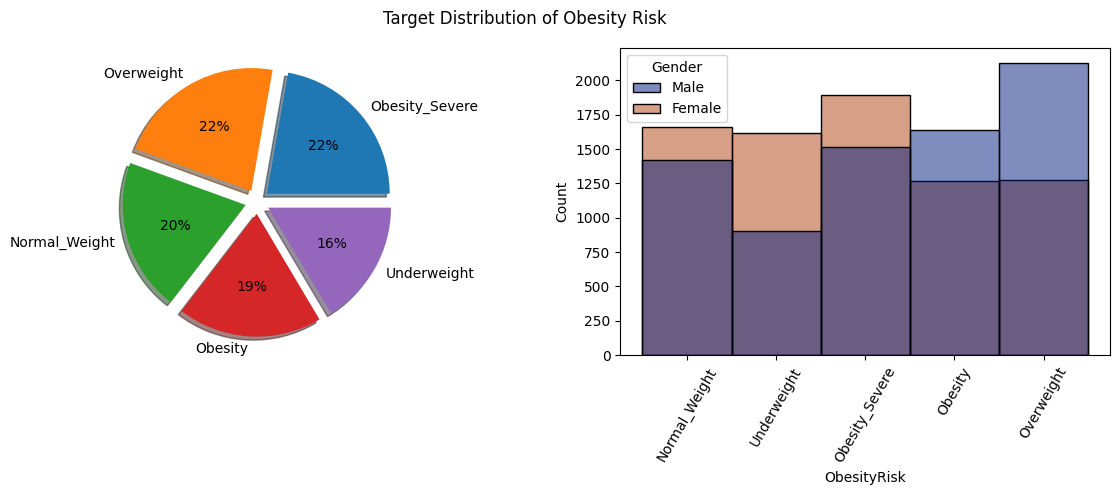

In [ ]:
fig, axs = plt.subplots(1,2,figsize = (12,5))
plt.suptitle("Target Distribution of Obesity Risk")

axs[0].pie(
        data_df[TARGET].value_counts(),
        shadow = True,
        explode=[.1 for i in range(data_df[TARGET].nunique())],
        labels = data_df[TARGET].value_counts().index,
        autopct='%1.f%%',
    )

sns.histplot(binwidth=0.5,x=TARGET,data=data_df,hue='Gender',palette="dark",ax=axs[1],discrete=True)
axs[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

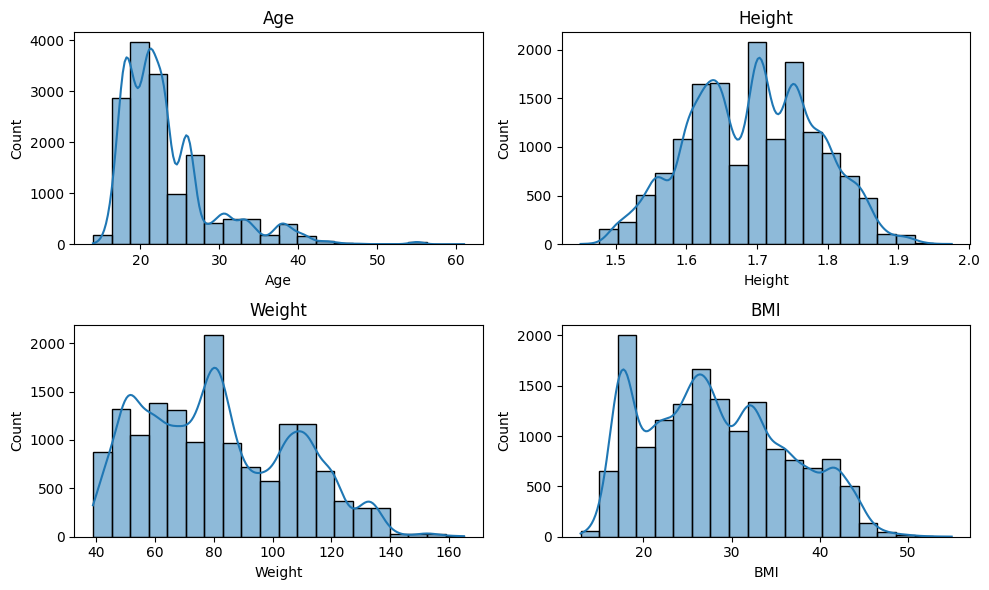

In [ ]:
# Create a 2x2 plot for histograms
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))

# Flatten the axis array to loop through the axes
axs = axs.flatten()

# Loop through numerical columns and plot histograms
for i, col in enumerate(raw_num_cols):
    # Plot histogram for each column
    sns.histplot(data_df[col], ax=axs[i], bins=20, kde=True, stat='count')  # Adjust the number of bins as needed
    axs[i].set_title(col)
    # axs[i].grid(False)  # Remove grid lines

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

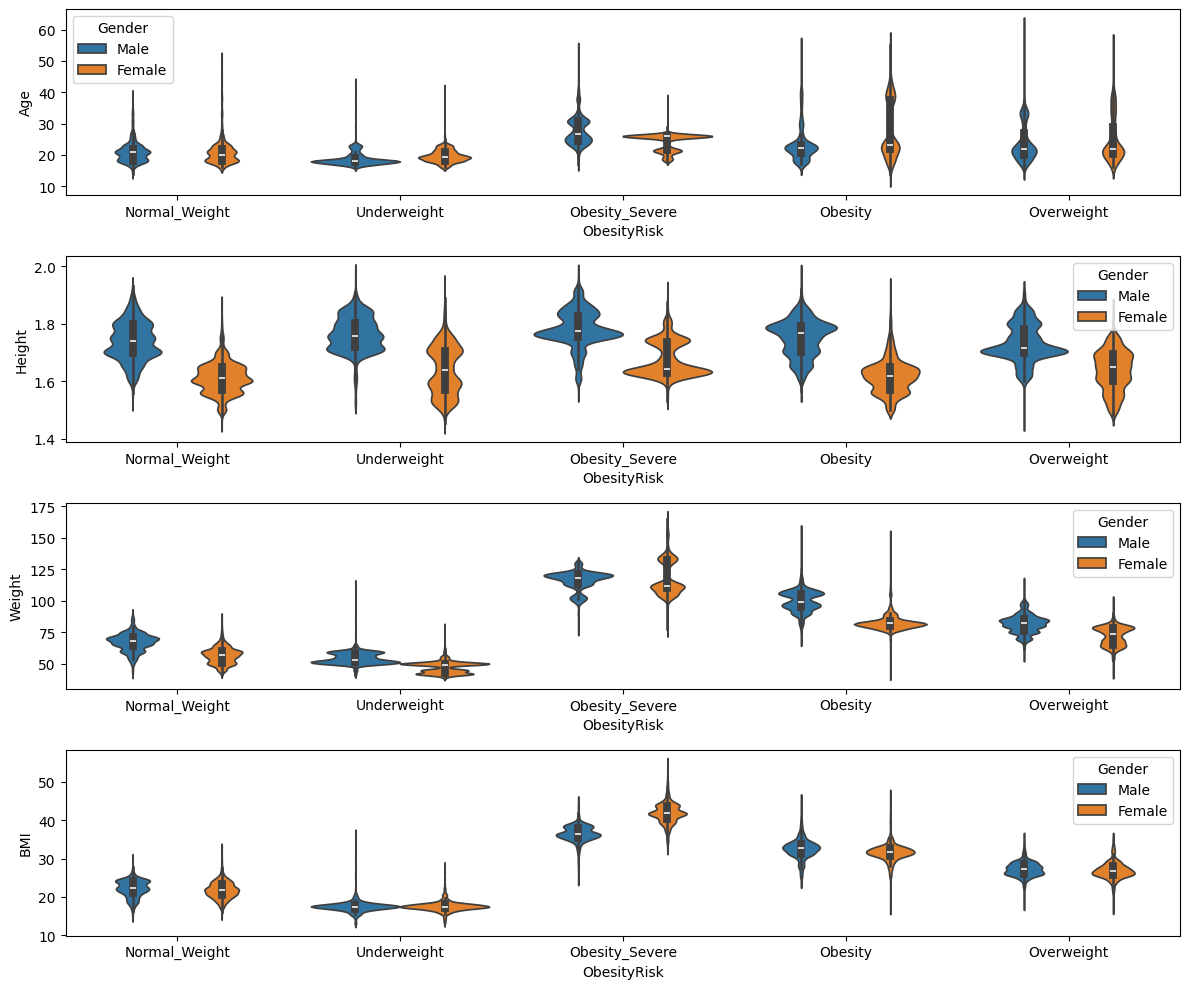

In [ ]:
fig,axs = plt.subplots(len(raw_num_cols),1,figsize=(12,len(raw_num_cols)*2.5),sharex=False)

for i, col in enumerate(raw_num_cols):
    sns.violinplot(x=TARGET, y=col,hue="Gender", data=data_df,ax = axs[i], split=False)

plt.tight_layout()
plt.show()

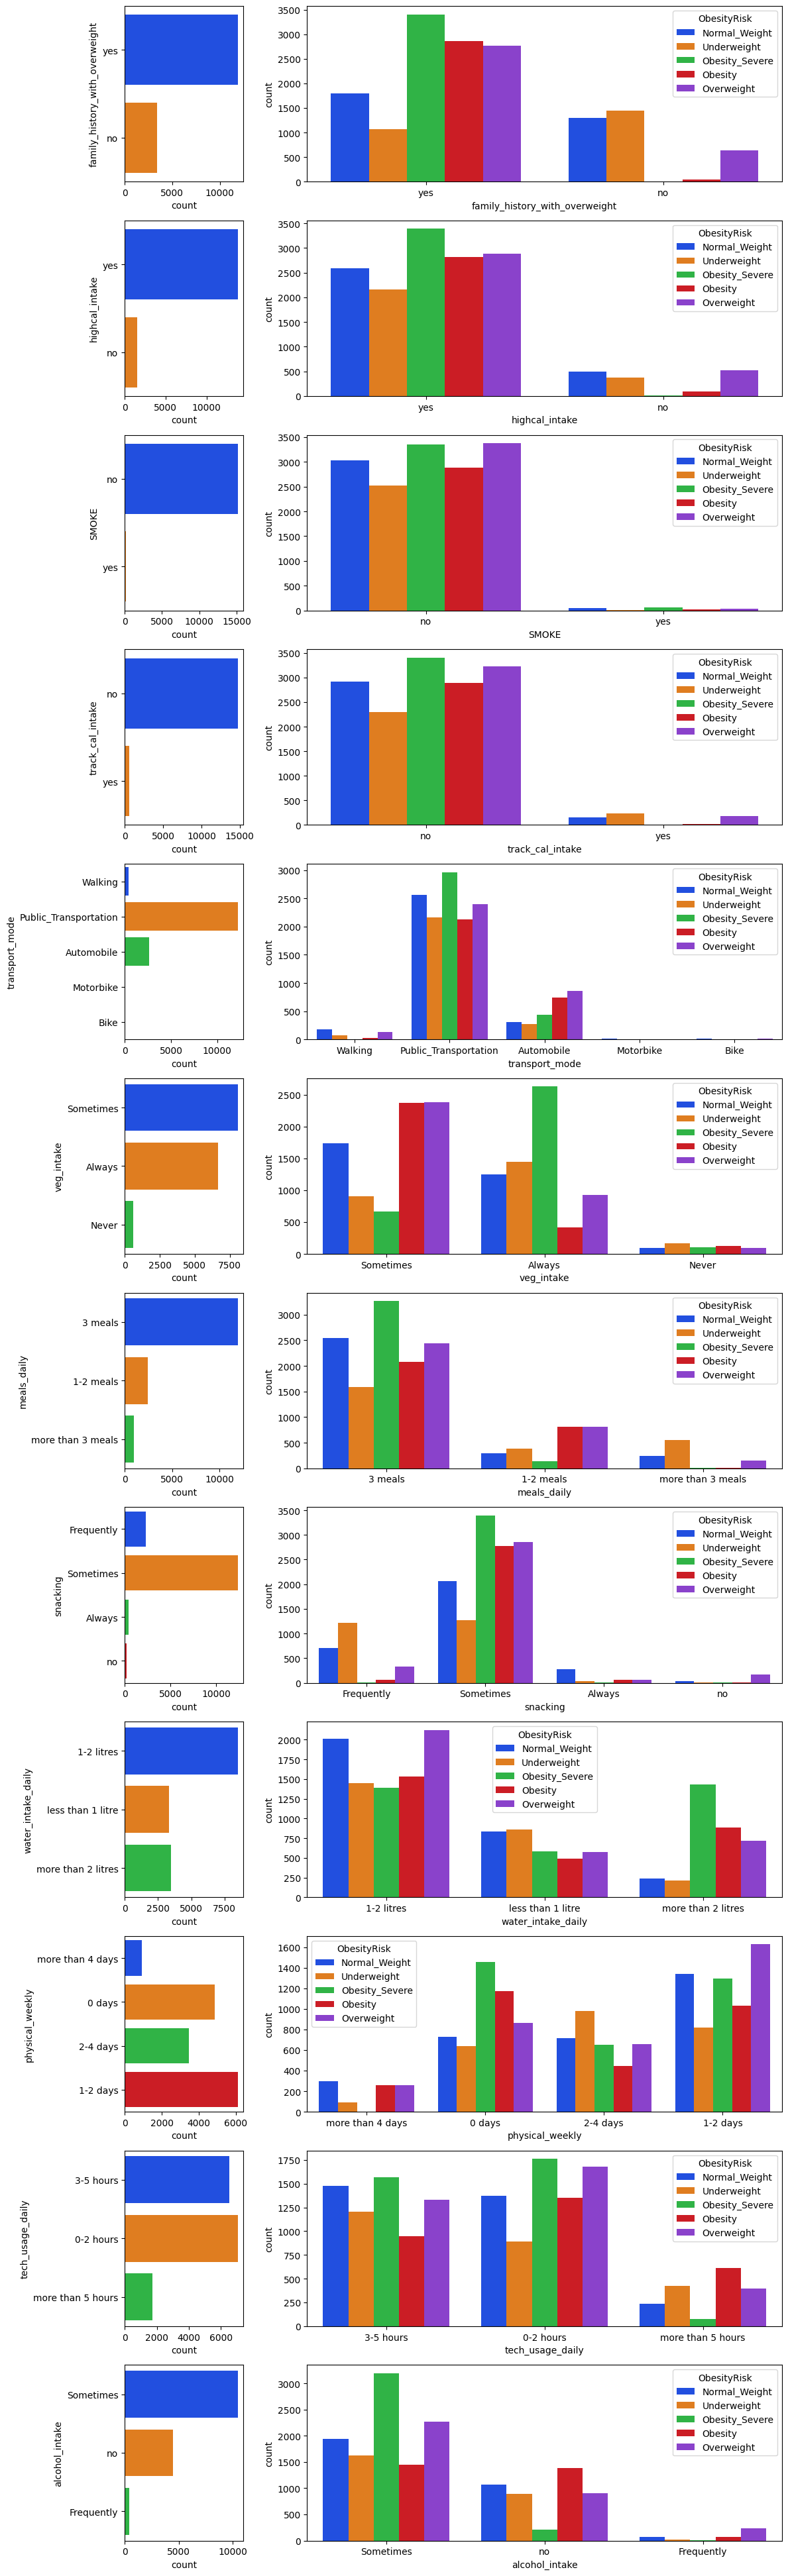

In [ ]:
_,axs = plt.subplots(int(len(raw_cat_cols)-1),2,figsize=(12,len(raw_cat_cols)*3),width_ratios=[1, 4])
for i,col in enumerate(raw_cat_cols[1:]):
    sns.countplot(y=col,data=data_df,palette="bright",ax=axs[i,0])
    sns.countplot(x=col,data=data_df,hue=TARGET,palette="bright",ax=axs[i,1])

plt.tight_layout()
plt.show()

In [ ]:
data_df[raw_num_cols].corr("pearson")

,Age,Height,Weight,BMI
Age,1.00,-0.05,0.30,0.36
Height,-0.05,1.00,0.41,0.10
Weight,0.30,0.41,1.00,0.94
BMI,0.36,0.10,0.94,1.00


<Axes: >

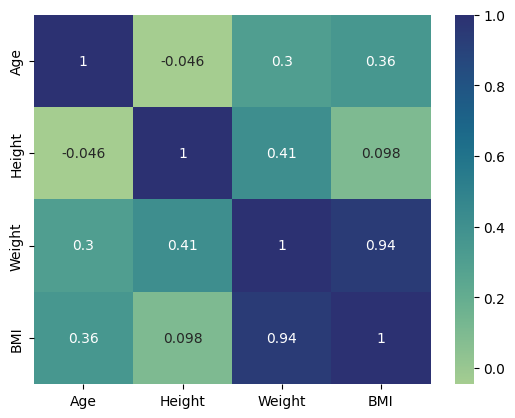

In [ ]:
corr_matrix = data_df[raw_num_cols].corr("pearson")
sns.heatmap(corr_matrix, annot=True, cmap ="crest")

In [ ]:
numerical_cols = ['Age']  # 'Height', 'Weight', 'BMI'
ordinal_cols = ['veg_intake', 'meals_daily', 'snacking', 'water_intake_daily', 'physical_weekly', 'tech_usage_daily', 'alcohol_intake']
binary_cols = ['Gender', 'family_history_with_overweight', 'highcal_intake', 'SMOKE', 'track_cal_intake']
categorical_cols = ['transport_mode']
onehot_cols = binary_cols + categorical_cols

In [ ]:
ordinal = OrdinalEncoder(categories = [
                            ['Never', 'Sometimes', 'Always'], # veg_intake
                            ['1-2 meals', '3 meals', 'more than 3 meals'], # meals_daily
                            ['no', 'Sometimes', 'Frequently', 'Always'], # snacking
                            ['less than 1 litre', '1-2 litres', 'more than 2 litres'], # water_intake_daily
                            ['0 days', '1-2 days', '2-4 days', 'more than 4 days'], # physical_weekly
                            ['0-2 hours', '3-5 hours', 'more than 5 hours'], # tech_usage_daily
                            ['no', 'Sometimes', 'Frequently'] # alcohol_intake
                         ],
                         handle_unknown = 'use_encoded_value',
                         unknown_value = -1
                        )

onehot = OneHotEncoder(categories = [
                            ['Female', 'Male'], # Gender
                            ['no', 'yes'], # family_history_with_overweight
                            ['no', 'yes'], # highcal_intake
                            ['no', 'yes'], # SMOKE
                            ['no', 'yes'], # track_cal_intake
                            ['Walking', 'Public_Transportation', 'Automobile', 'Motorbike', 'Bike'] # transport_mode
                         ],
                         handle_unknown = 'ignore',
                        )

# Combine them!
encoder = ColumnTransformer([
   # List of (name, transformer, columns) tuples specifying the transformer objects to be applied to subsets of the data.
    ('numerical', 'passthrough', numerical_cols),   # <- 'passthrough' says to keep them but don't apply anything
    ('ordinal', ordinal, ordinal_cols),             # <- apply ordinal encoder to the ordinal_columns
    ('onehot', onehot, onehot_cols)                 # <- apply onehot encoder to the onehot_columns
])

encoder


ColumnTransformer(transformers=[('numerical', 'passthrough', ['Age']),
                                ('ordinal',
                                 OrdinalEncoder(categories=[['Never',
                                                             'Sometimes',
                                                             'Always'],
                                                            ['1-2 meals',
                                                             '3 meals',
                                                             'more than 3 '
                                                             'meals'],
                                                            ['no', 'Sometimes',
                                                             'Frequently',
                                                             'Always'],
                                                            ['less than 1 '
                                                             'litre',
                                                             '1-2 litres',
                                                             'more than 2 '
                                                             'litres'],
                                                            ['0 days',
                                                             '1-2 days',
                                                             '2-4 days',
                                                             'more than 4 '
                                                             'days'],
                                                            ['0-2 hours',
                                                             '3-5 hours',
                                                             'more th...
                                  'water_intake_daily', 'physical_weekly',
                                  'tech_usage_daily', 'alcohol_intake']),
                                ('onehot',
                                 OneHotEncoder(categories=[['Female', 'Male'],
                                                           ['no', 'yes'],
                                                           ['no', 'yes'],
                                                           ['no', 'yes'],
                                                           ['no', 'yes'],
                                                           ['Walking',
                                                            'Public_Transportation',
                                                            'Automobile',
                                                            'Motorbike',
                                                            'Bike']],
                                               handle_unknown='ignore'),
                                 ['Gender', 'family_history_with_overweight',
                                  'highcal_intake', 'SMOKE', 'track_cal_intake',
                                  'transport_mode'])])

In [ ]:
# Define the label mapping dictionary
label_mapping = {
    'Underweight': 0,
    'Normal_Weight': 1,
    'Overweight': 2,
    'Obesity': 3,
    'Obesity_Severe': 4
}

# Map the labels to integers
data_df['ObesityRisk'] = data_df['ObesityRisk'].map(label_mapping)

print(data_df['ObesityRisk'].unique())

[1 0 4 3 2]


In [ ]:
# Separate target variable & features
X = data_df.drop(columns = ['id','ObesityRisk', 'Height', 'Weight', 'BMI'])  #'Height', 'Weight', 'BMI'
y = data_df['ObesityRisk']

print(X.shape, y.shape)

(15327, 14) (15327,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify = y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(12261, 14) (3066, 14) (12261,) (3066,)


In [ ]:
print(y_train.head())
X_train.head()

13870    0
8962     1
12769    1
6937     1
5628     3
Name: ObesityRisk, dtype: int64


,Gender,Age,family_history_with_overweight,highcal_intake,veg_intake,meals_daily,snacking,SMOKE,water_intake_daily,track_cal_intake,physical_weekly,tech_usage_daily,alcohol_intake,transport_mode
13870,Female,19.00,no,yes,Sometimes,3 meals,Sometimes,no,less than 1 litre,no,1-2 days,3-5 hours,Sometimes,Public_Transportation
8962,Male,22.00,no,yes,Sometimes,3 meals,Sometimes,no,less than 1 litre,yes,0 days,more than 5 hours,no,Public_Transportation
12769,Female,23.00,yes,yes,Sometimes,3 meals,Sometimes,no,1-2 litres,no,0 days,3-5 hours,Sometimes,Public_Transportation
6937,Male,23.00,yes,no,Never,more than 3 meals,Frequently,no,1-2 litres,no,2-4 days,3-5 hours,Sometimes,Public_Transportation
5628,Male,21.01,yes,yes,Always,3 meals,Sometimes,no,1-2 litres,no,1-2 days,3-5 hours,Sometimes,Public_Transportation


In [ ]:
lr = LogisticRegression(
    class_weight='balanced', # ensure balanced weights to account for class imbalance
    random_state=7,
    max_iter=1000
)

# Initialise standard scaler
scaler = StandardScaler()

pipe_lr =  Pipeline([
    ('encoder', encoder),
    ('scaler', scaler),
    ('lr', lr)
])

# Parameters to search over
param_grid = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization parameter
    'lr__penalty': [None, 'l1', 'l2']  # Penalty term
}

### Validator ###
# Use 5 k-fold, considering the size of the dataset & computational power
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

## GridSearch ###
grid = GridSearchCV(pipe_lr,       # model to use
                    param_grid, # parameters to search over
                    scoring = ['balanced_accuracy', 'f1_weighted'], # metrics to compute
                    refit = 'f1_weighted',  # which metric to use to decide the best model
                    cv = cv,
                    n_jobs = -1
                   )

grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=7, shuffle=True),
             estimator=Pipeline(steps=[('encoder',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         'passthrough',
                                                                         ['Age']),
                                                                        ('ordinal',
                                                                         OrdinalEncoder(categories=[['Never',
                                                                                                     'Sometimes',
                                                                                                     'Always'],
                                                                                                    ['1-2 '
                                                                                                     'meals',
                                                                                                     '3 '
                                                                                                     'meals',
                                                                                                     'more '
                                                                                                     'than '
                                                                                                     '3 '
                                                                                                     'meals'],
                                                                                                    ['no',
                                                                                                     'Sometimes',
                                                                                                     'Frequently',
                                                                                                     'Always'],
                                                                                                    ['less '
                                                                                                     'than '
                                                                                                     '...
                                                                          'family_history_with_overweight',
                                                                          'highcal_intake',
                                                                          'SMOKE',
                                                                          'track_cal_intake',
                                                                          'transport_mode'])])),
                                       ('scaler', StandardScaler()),
                                       ('lr',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=7))]),
             n_jobs=-1,
             param_grid={'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'lr__penalty': [None, 'l1', 'l2']},
             refit='f1_weighted', scoring=['balanced_accuracy', 'f1_weighted'])

In [ ]:
# Best hyperparams
{'xgb__subsample': 0.6, 'xgb__reg_lambda': 1, 'xgb__reg_alpha': 0.5, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.1}
0.7172519648737294

0.7172519648737294

In [ ]:
xgb = XGBClassifier(booster='gbtree', learning_rate=0.1, max_depth=7, subsample=0.6, reg_lambda=1, reg_alpha=0.5, random_state=7)

pipe_xgb =  Pipeline([
    ('encoder', encoder),
    ('xgb', xgb)
])

pipe_xgb.fit(X_train, y_train)

y_pred = pipe_xgb.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.75      0.76       505
           1       0.63      0.66      0.64       617
           2       0.62      0.54      0.57       681
           3       0.68      0.69      0.69       582
           4       0.86      0.94      0.90       681

    accuracy                           0.72      3066
   macro avg       0.71      0.72      0.71      3066
weighted avg       0.71      0.72      0.71      3066



<Figure size 1000x800 with 0 Axes>

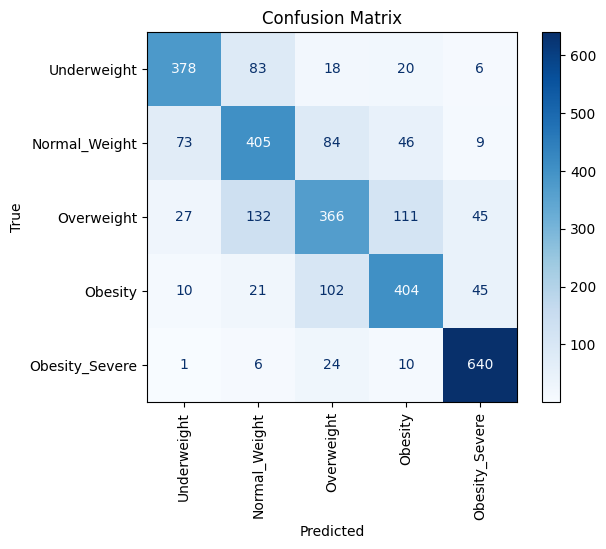

In [ ]:
# Define class labels
class_labels_num = [0, 1, 2, 3, 4]
class_labels = ['Underweight', 'Normal_Weight', 'Overweight', 'Obesity', 'Obesity_Severe']

# Get the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=class_labels_num)

# Create ConfusionMatrixDisplay
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
cm_display.plot(cmap='Blues', xticks_rotation='vertical', values_format='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Weight,Feature
0.2734 ± 0.0076,numerical__Age
0.0934 ± 0.0102,ordinal__veg_intake
0.0898 ± 0.0074,onehot__family_history_with_overweight_no
0.0693 ± 0.0044,ordinal__snacking
0.0641 ± 0.0013,onehot__Gender_Female
0.0402 ± 0.0059,ordinal__alcohol_intake
0.0295 ± 0.0057,ordinal__meals_daily
0.0235 ± 0.0046,ordinal__water_intake_daily
0.0230 ± 0.0026,onehot__transport_mode_Public_Transportation
0.0207 ± 0.0050,ordinal__physical_weekly


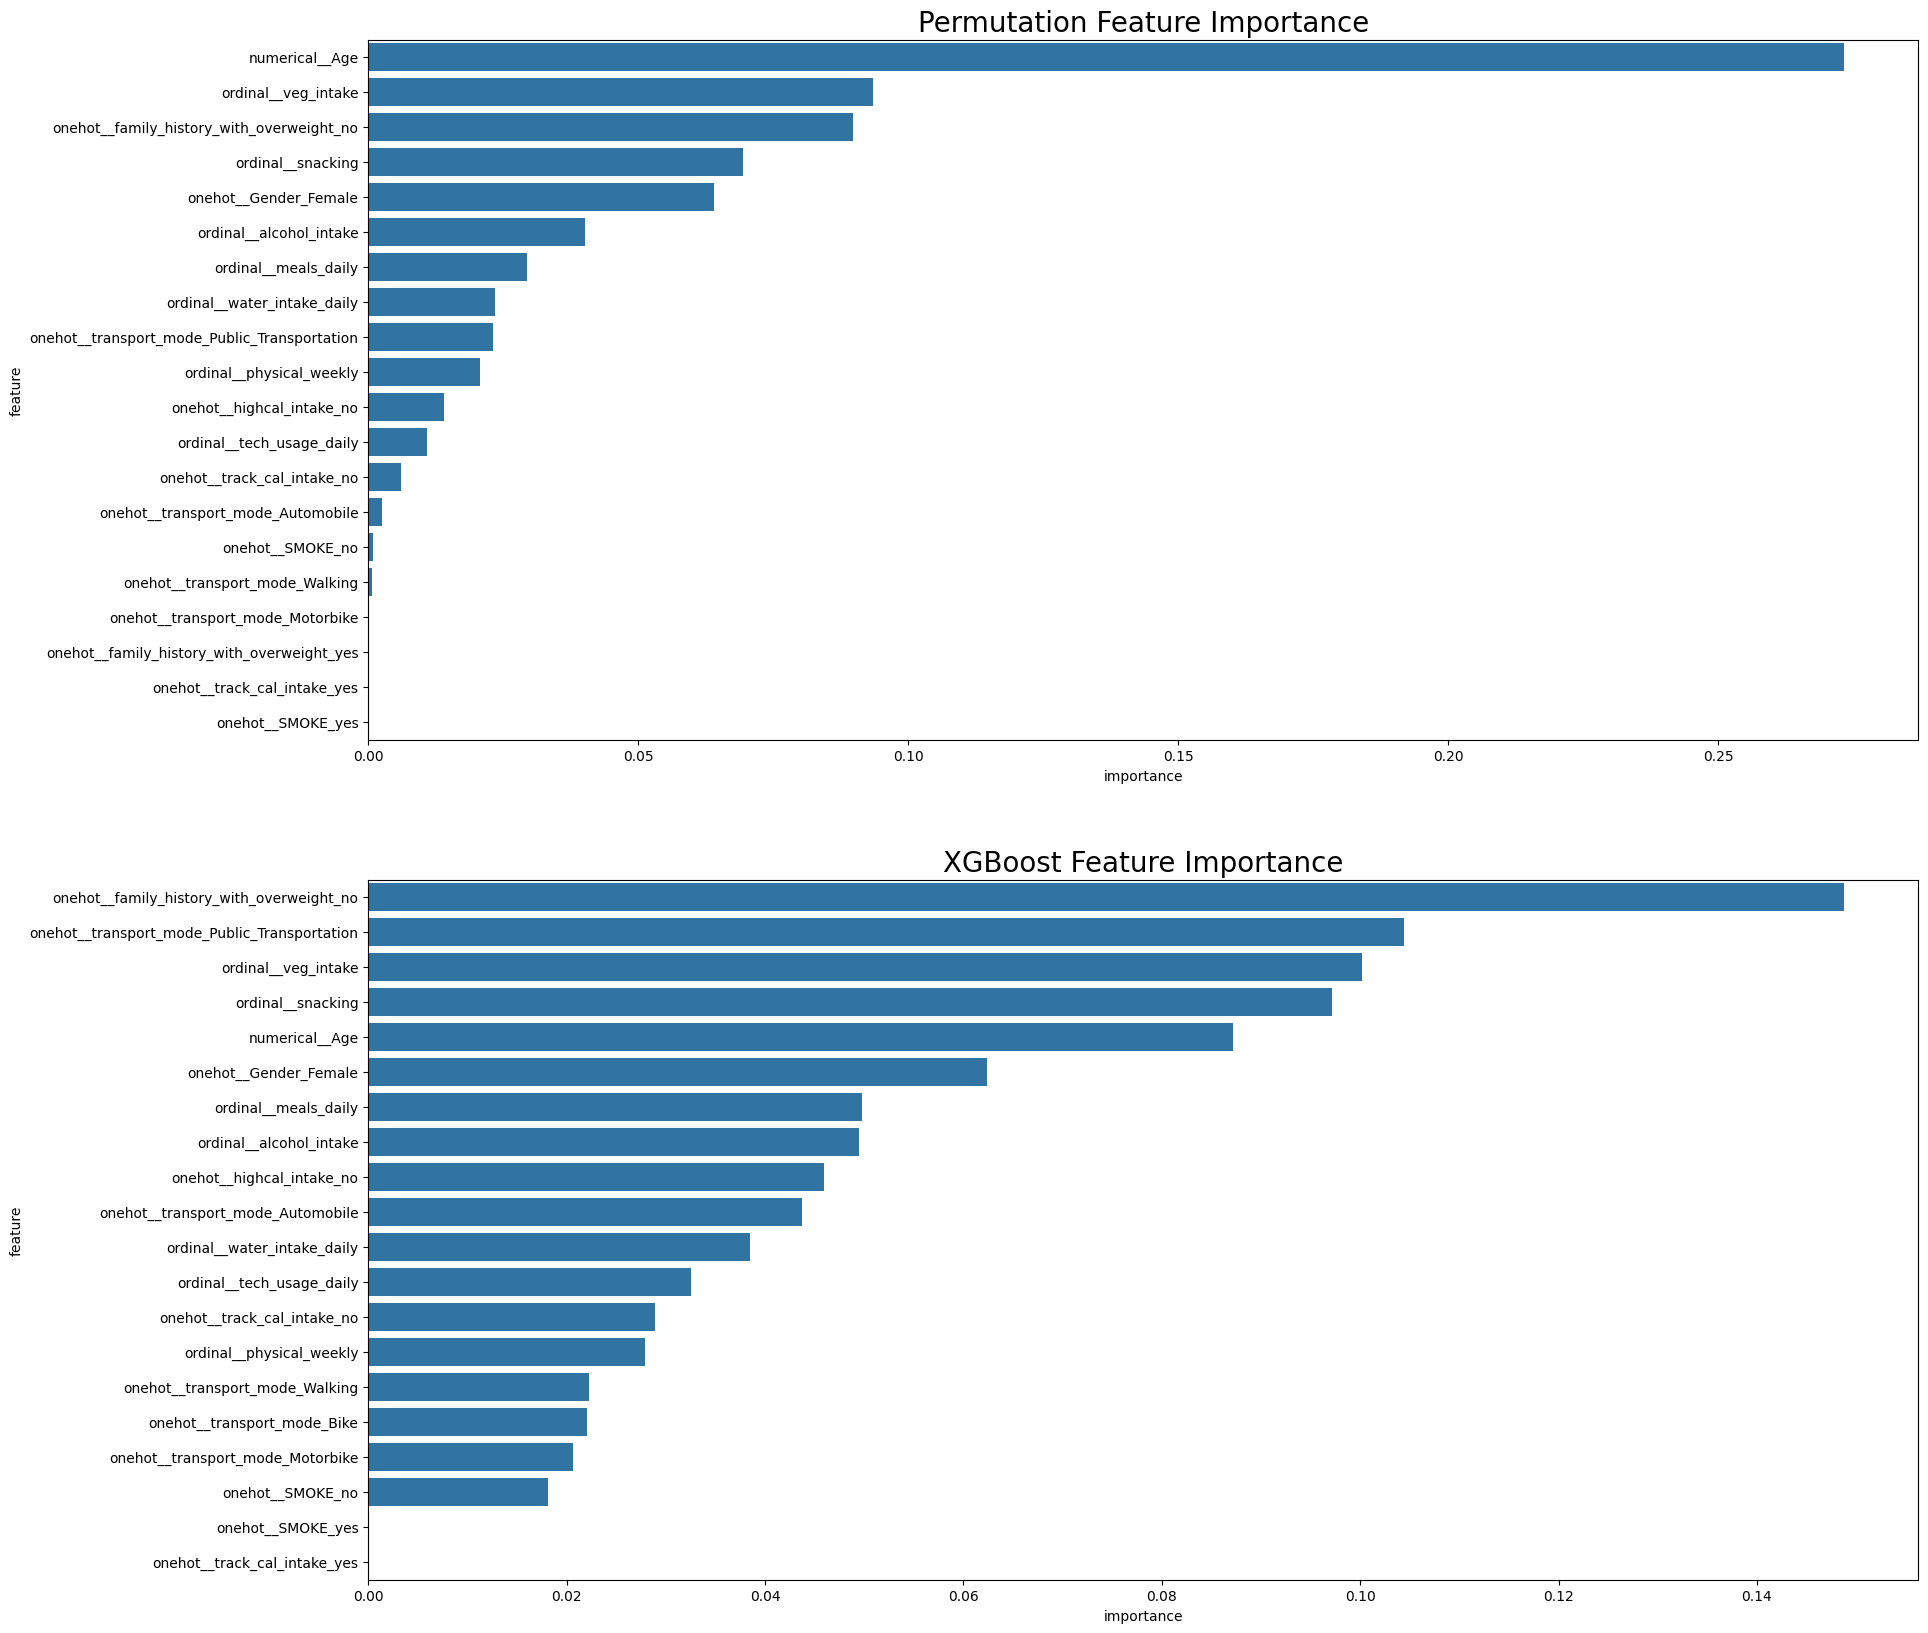

In [ ]:
# Get the feature names from the encoder
feature_names = pipe_xgb.named_steps['encoder'].get_feature_names_out()

# Ensure test data is encoded using the same encoder
X_test_encoded = pipe_xgb.named_steps['encoder'].transform(X_test)

# Permutation Feature Importance
perm = PermutationImportance(pipe_xgb.named_steps['xgb'], random_state=7).fit(X_test_encoded, y_test)

# Store Permutation feature importance details in the dataframe for further analysis
perm_df = pd.DataFrame()
perm_df["feature"] = feature_names  # Use the feature names obtained from the encoder
perm_df["importance"] = perm.feature_importances_

# XGB Default Feature Importance
xgb_feature_importance_df = pd.DataFrame()
xgb_feature_importance_df["feature"] = feature_names
xgb_feature_importance_df["importance"] = pipe_xgb.named_steps['xgb'].feature_importances_

# Plot PFI chart
fig, axes = plt.subplots(2, 1, figsize=(20, 20))
plt.rcParams.update({'font.size': 12})

# Permutation Feature Importance
perm_feature_importance_df = perm_df.sort_values('importance', ascending=False).reset_index()
sns.barplot(x='importance', y='feature', data=perm_feature_importance_df[:20], ax=axes[0])
axes[0].set_title("Permutation Feature Importance", fontsize=20)

# Random Forest Default Feature Importance
feature_importance_df = xgb_feature_importance_df.sort_values('importance', ascending=False).reset_index()
sns.barplot(x='importance', y='feature', data=feature_importance_df[:20], ax=axes[1])
axes[1].set_title("XGBoost Feature Importance", fontsize=20)

# Visualize results
eli5.show_weights(perm, feature_names=feature_names)


In [ ]:
transformed_X_test_xgb = pipe_xgb.named_steps['encoder'].transform(X_test)

# Get the feature names from the encoder
feature_names_xgb = pipe_xgb.named_steps['encoder'].get_feature_names_out()

explainer_xgb = shap.TreeExplainer(pipe_xgb.named_steps['xgb'])
shap_values_xgb = explainer_xgb.shap_values(transformed_X_test_xgb)

In [ ]:
print(transformed_X_test_xgb.shape)
print(shap_values_xgb.shape)

(3066, 23)
(3066, 23, 5)


SHAP Values of Target: <Underweight>


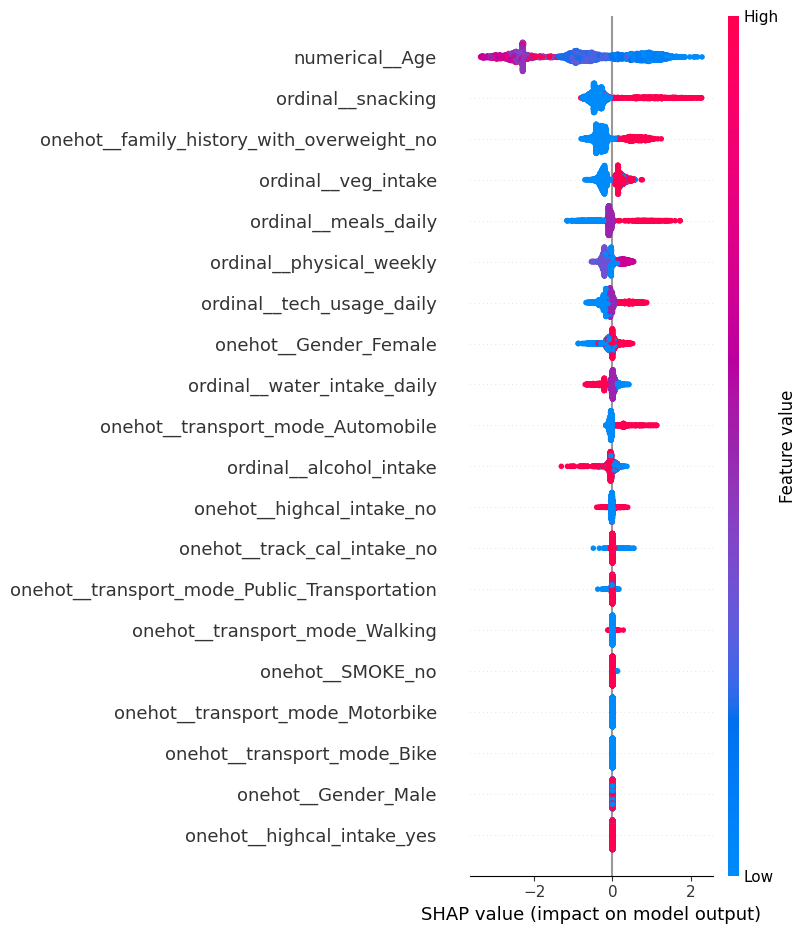

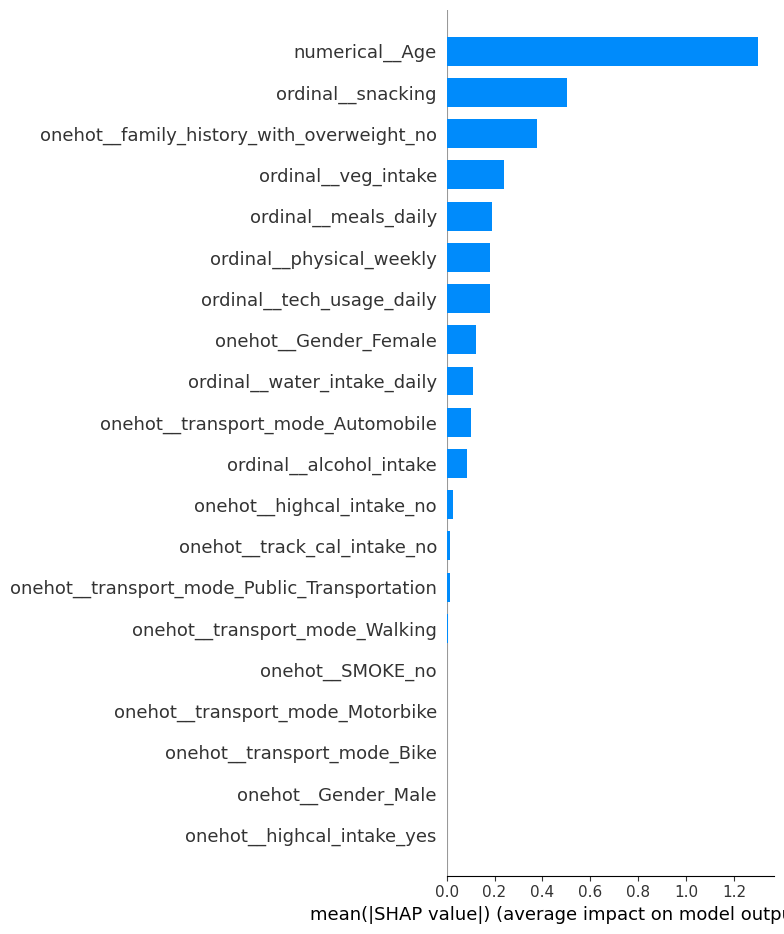

 
SHAP Values of Target: <Normal_Weight>


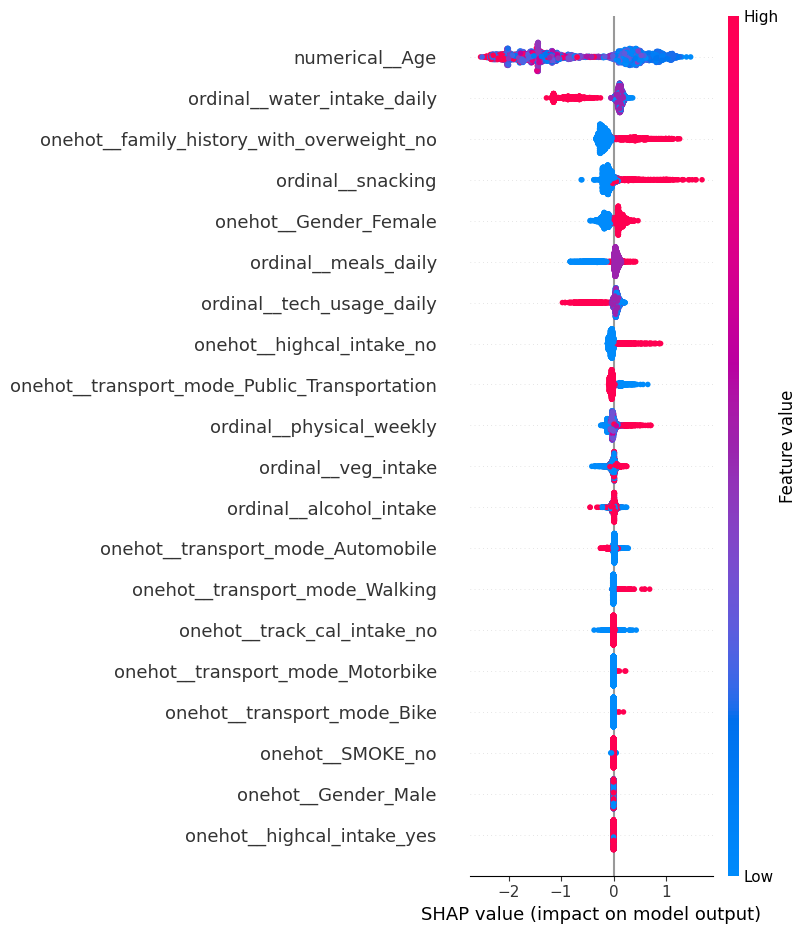

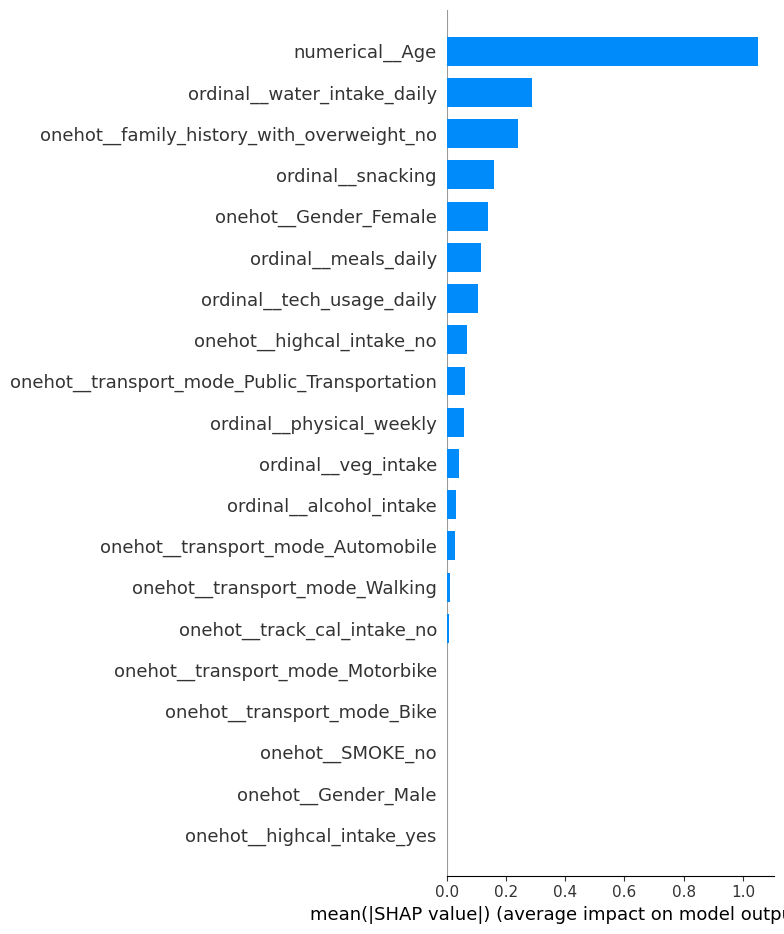

 
SHAP Values of Target: <Overweight>


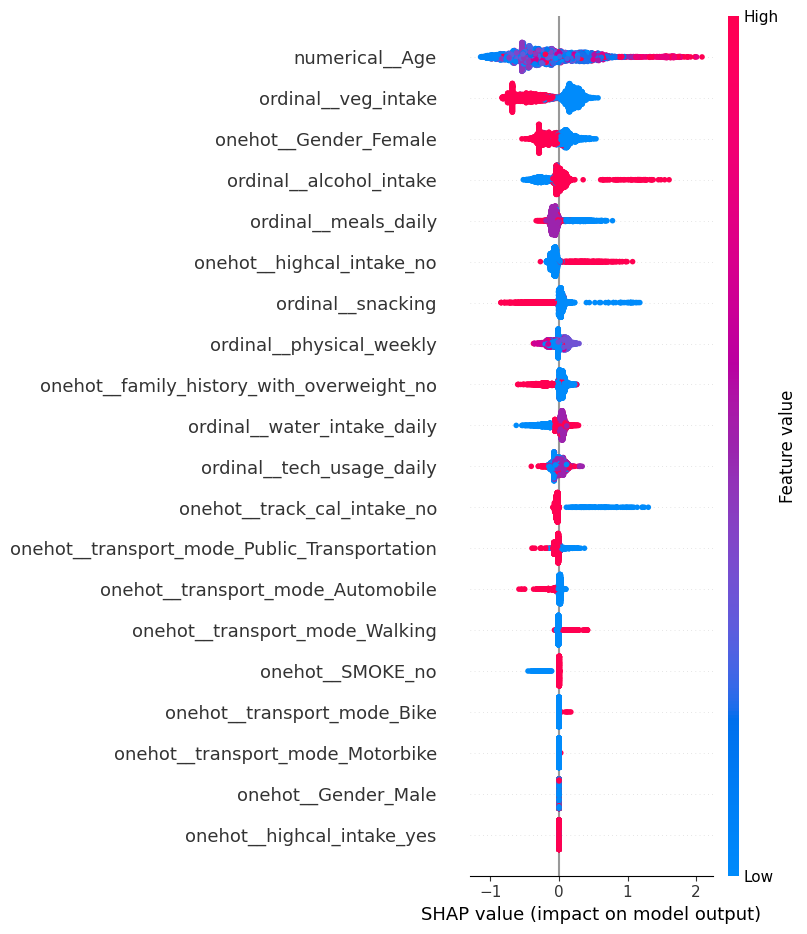

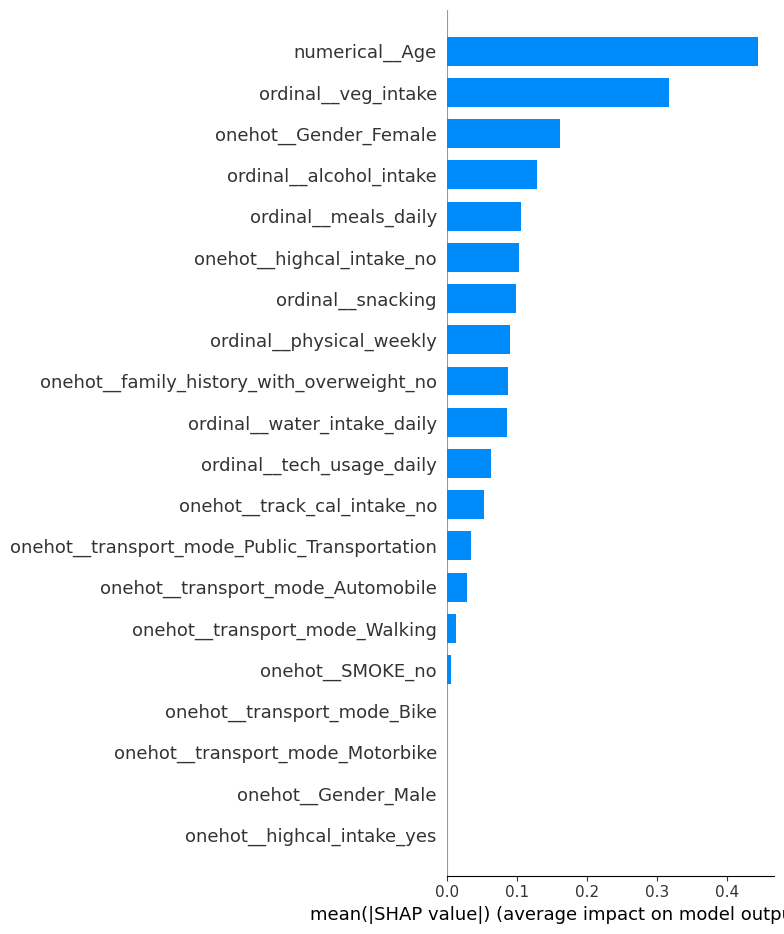

 
SHAP Values of Target: <Obesity>


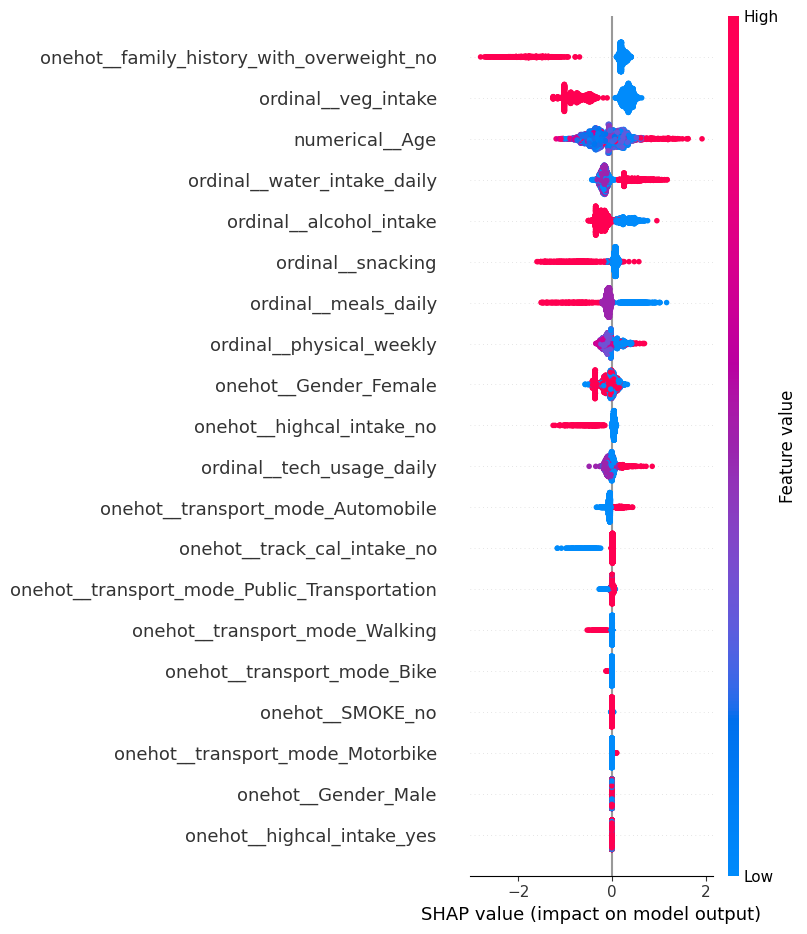

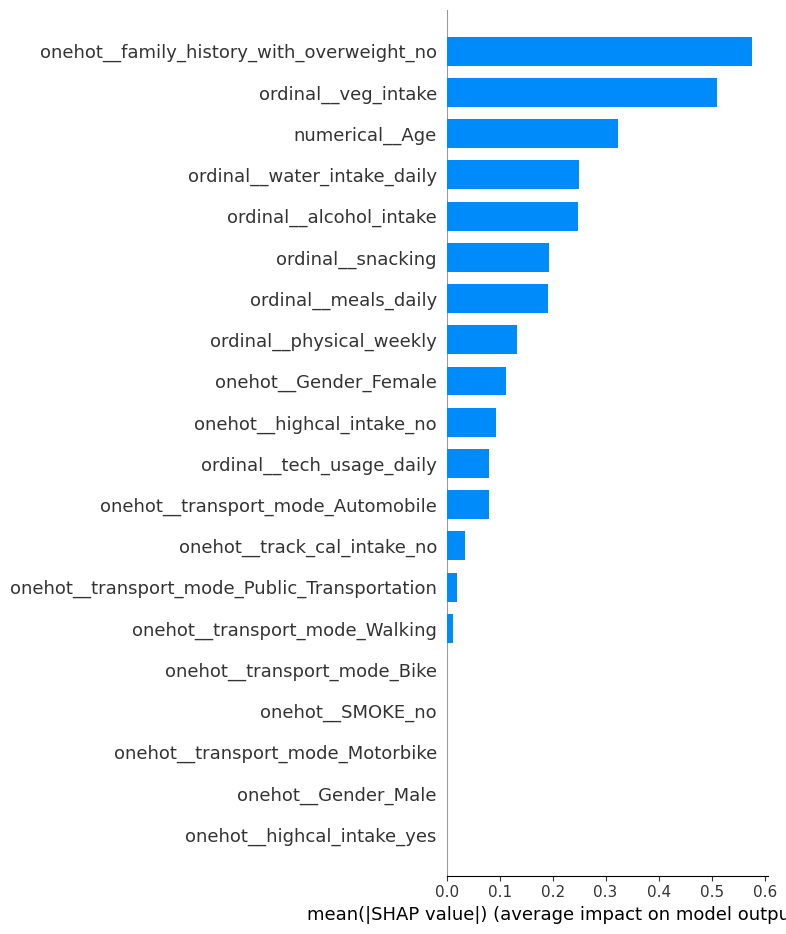

 
SHAP Values of Target: <Obesity_Severe>


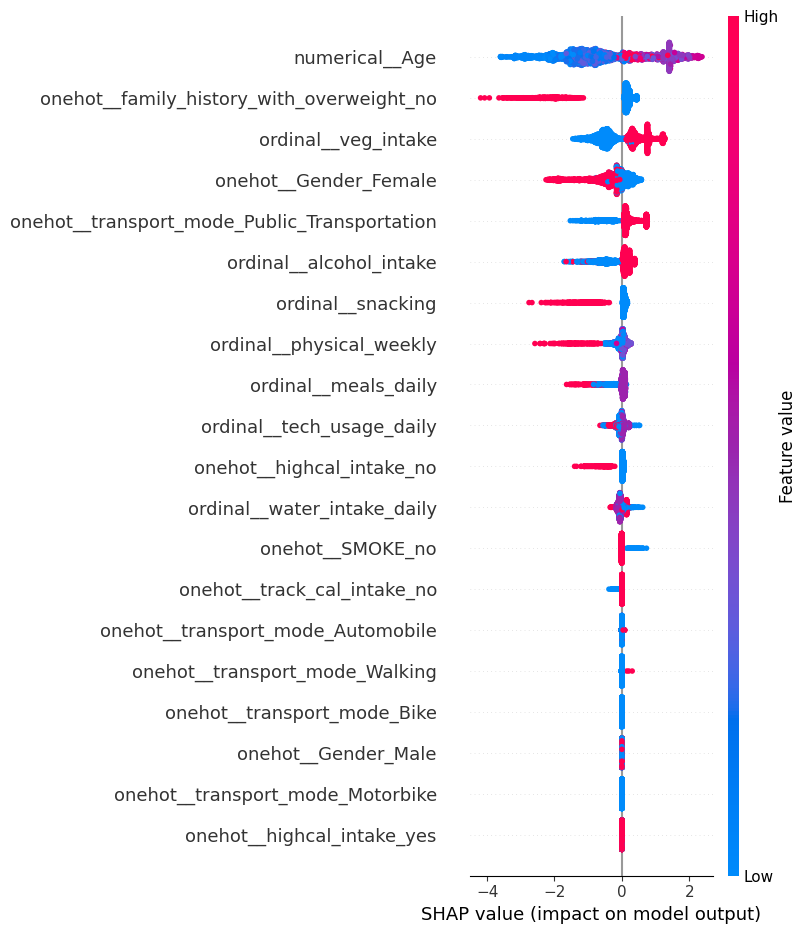

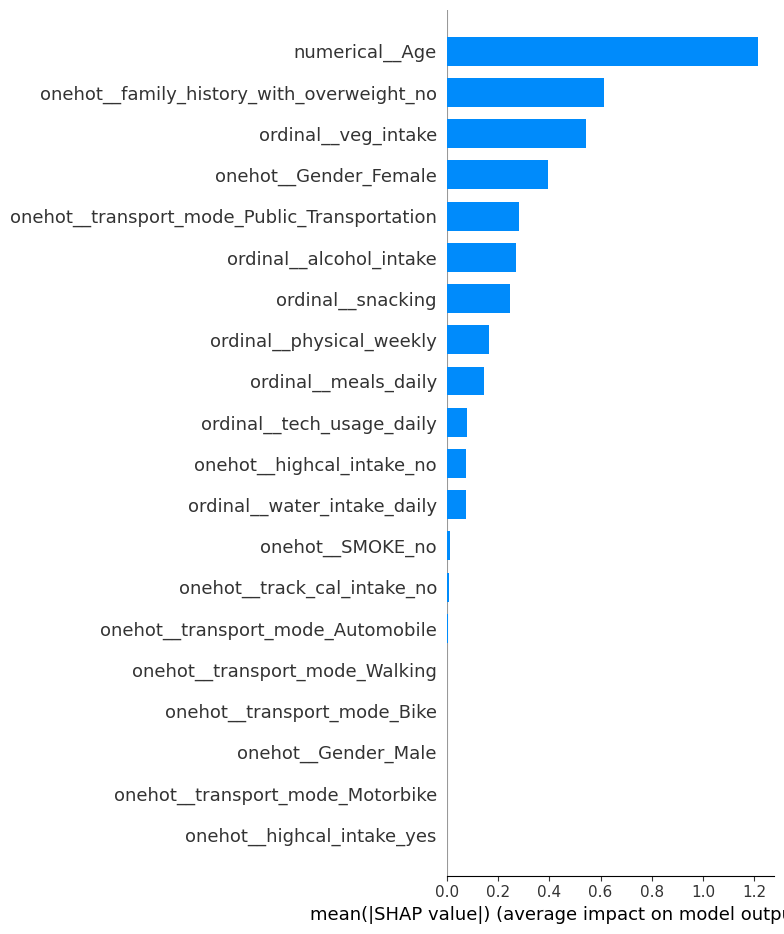

In [ ]:
# Define class labels
class_labels_num = [0, 1, 2, 3, 4]
class_labels = ['Underweight', 'Normal_Weight', 'Overweight', 'Obesity', 'Obesity_Severe']


for target_label in class_labels_num:
    print(f"SHAP Values of Target: <{class_labels[target_label]}>")
    shap.summary_plot(shap_values_xgb[:,:,target_label], transformed_X_test_xgb, feature_names=feature_names_xgb)
    shap.summary_plot(shap_values_xgb[:,:,target_label], transformed_X_test_xgb, feature_names=feature_names_xgb, plot_type="bar")
    print(' ')

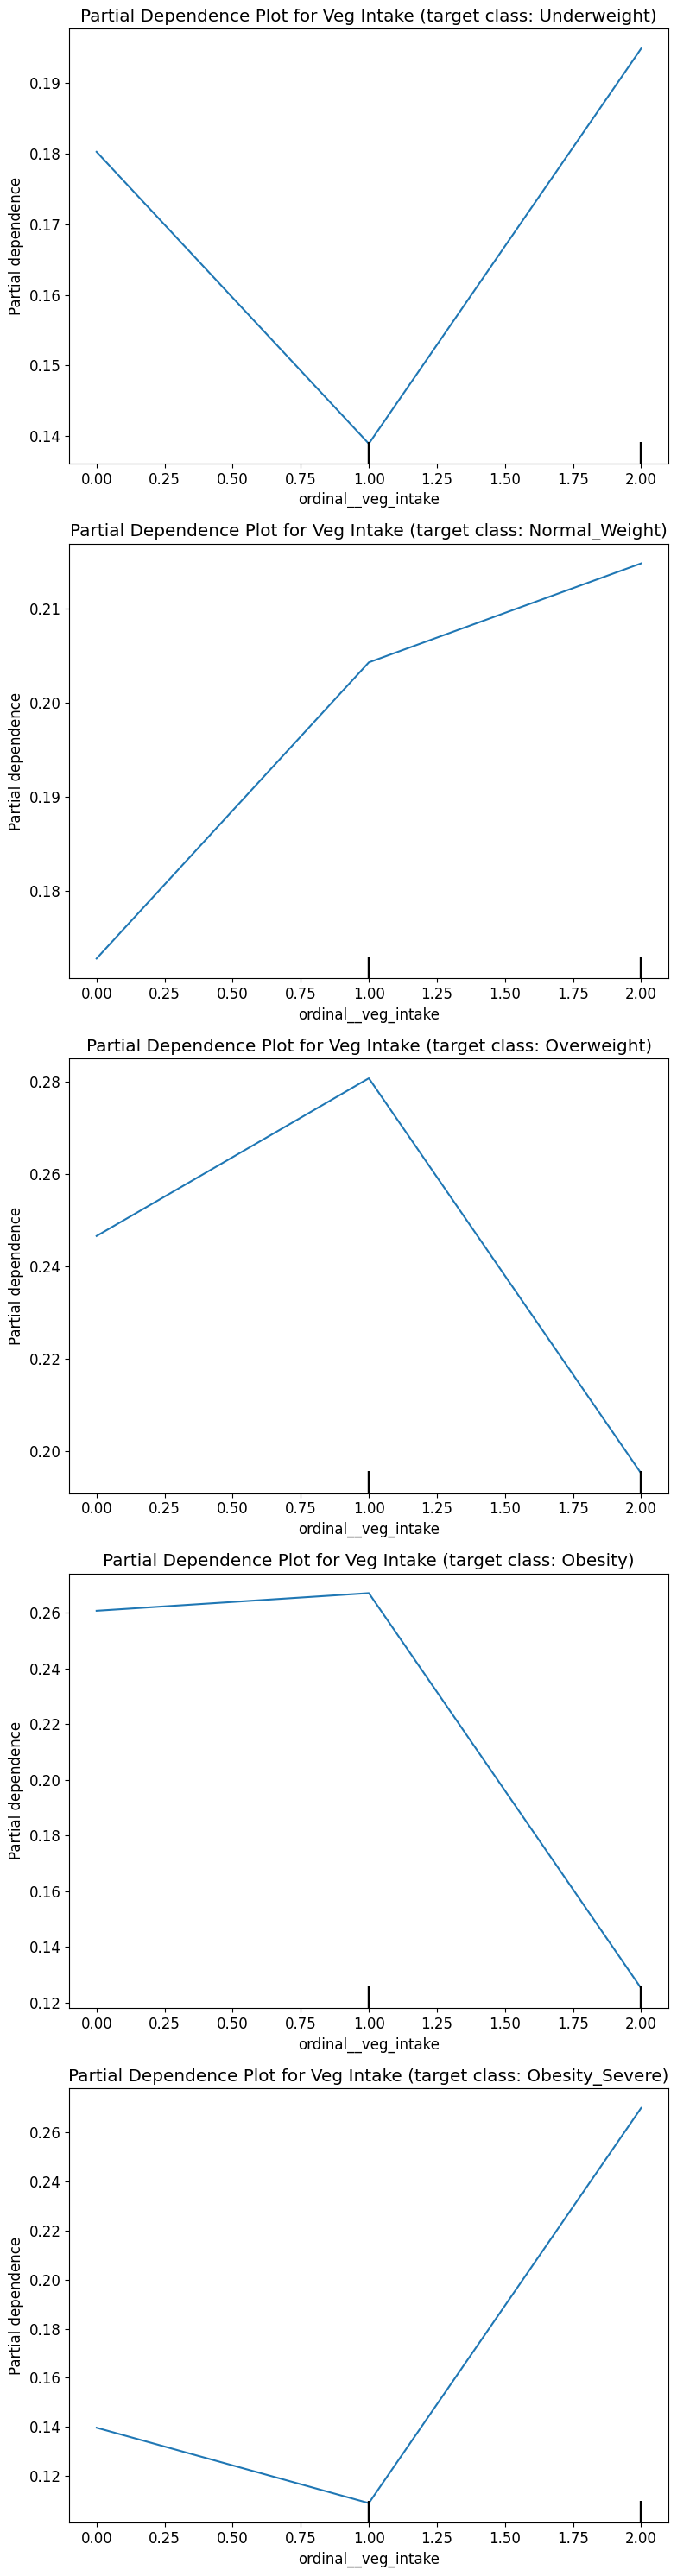

In [ ]:
# Find the index of 'ordinal__veg_intake' feature in the encoded feature list
# Get the feature names from the encoder
encoded_feature_names = pipe_xgb.named_steps['encoder'].get_feature_names_out()  # Define encoded_feature_names here

# Use np.where to find the index of the feature
Vegtable_intake = np.where(encoded_feature_names == 'ordinal__veg_intake')[0][0]

# Plot the partial dependence for each class
fig, axs = plt.subplots(nrows=len(label_mapping), figsize=(8, 6 * len(label_mapping)))

for i, (class_name, class_index) in enumerate(label_mapping.items()):
    ax = axs[i]
    display = PartialDependenceDisplay.from_estimator(xgb, encoder.transform(X_test), features=[Vegtable_intake], feature_names=encoded_feature_names, target=class_index, kind='average', ax=ax)
    ax.set_title(f'Partial Dependence Plot for Veg Intake (target class: {class_name})')

plt.tight_layout()
plt.show()

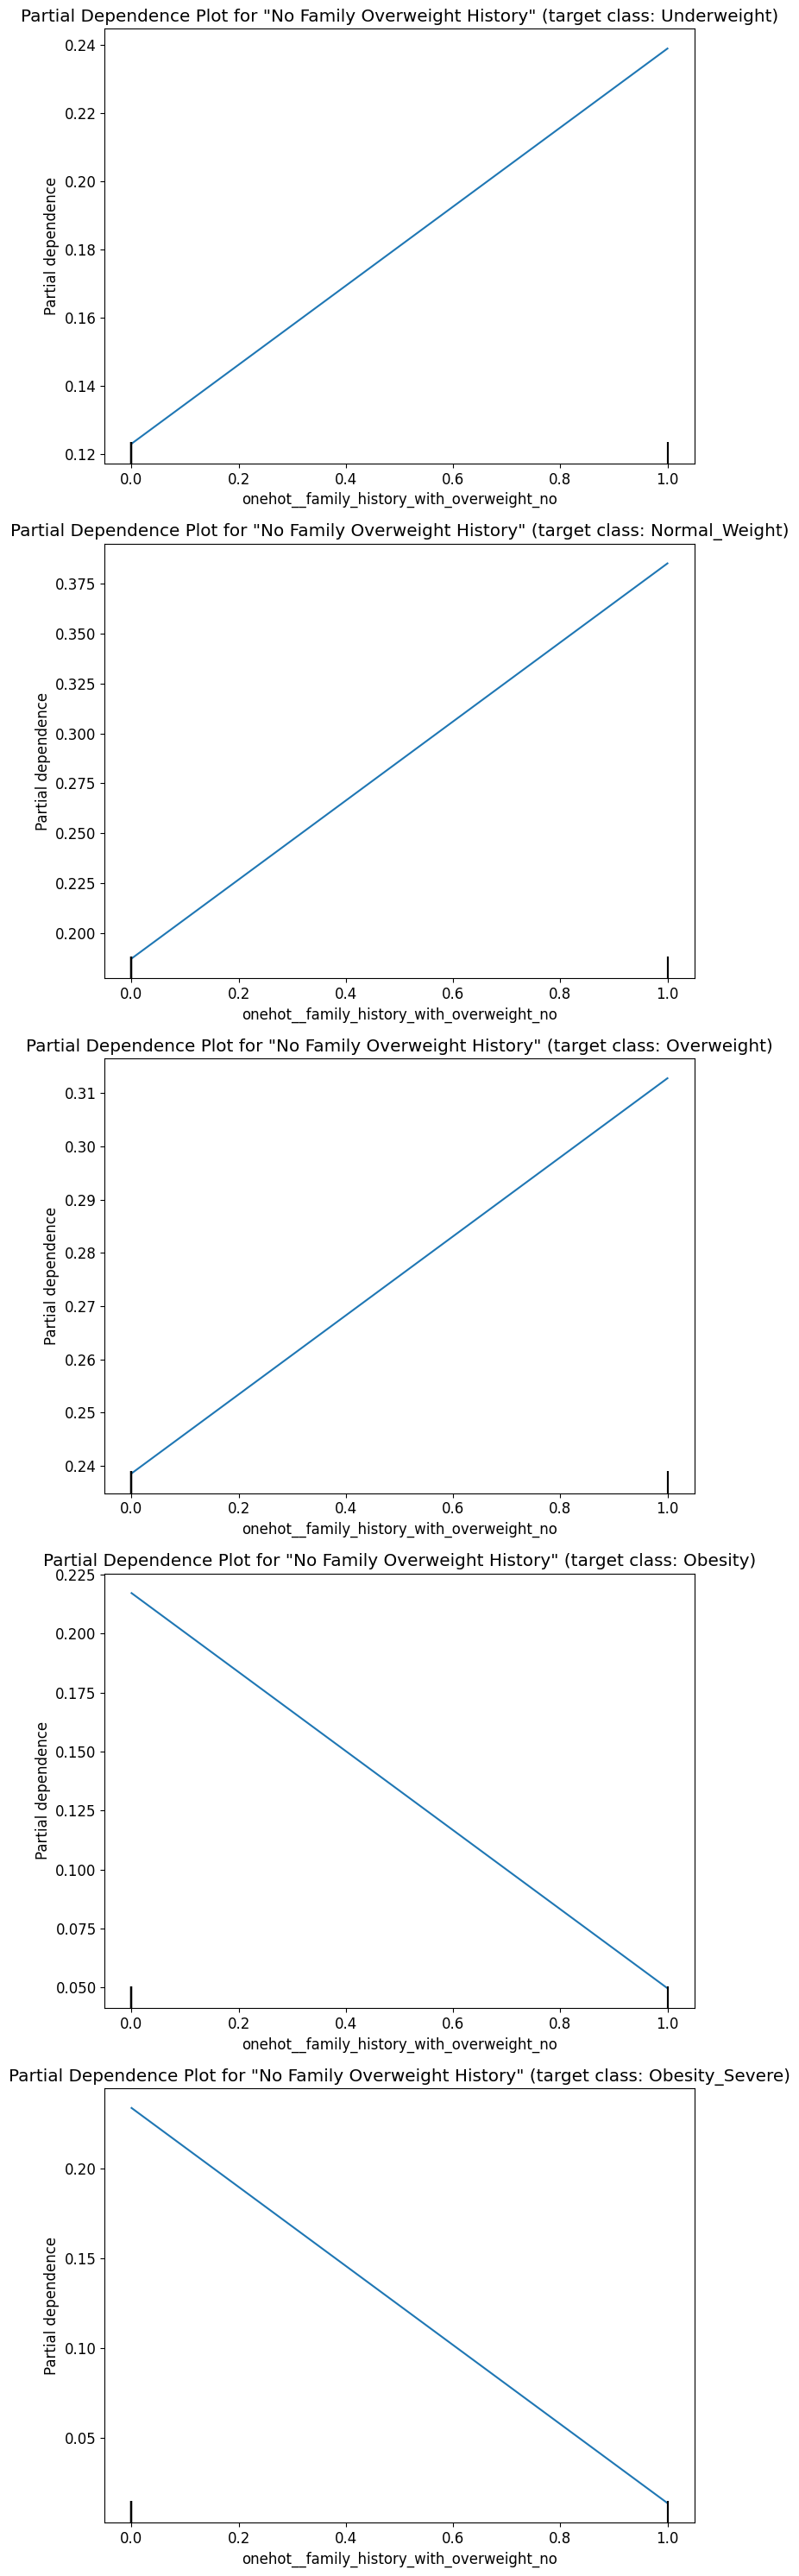

In [ ]:
# Find the index of 'onehot__family_history_with_overweight_no' feature in the encoded feature list
encoded_feature_names = pipe_xgb.named_steps['encoder'].get_feature_names_out()  # Define encoded_feature_names here

# Use np.where to find the index of the feature
# No_Family_Overweight = encoded_feature_names.index('onehot__family_history_with_overweight_no') # Incorrect: .index is not an attribute of numpy.ndarray
No_Family_Overweight = np.where(encoded_feature_names == 'onehot__family_history_with_overweight_no')[0][0] # Correct: Use np.where to find the index

# Plot the partial dependence for each class
fig, axs = plt.subplots(nrows=len(label_mapping), figsize=(8, 6 * len(label_mapping)))

for i, (class_name, class_index) in enumerate(label_mapping.items()):
    ax = axs[i]
    display = PartialDependenceDisplay.from_estimator(xgb, encoder.transform(X_test), features=[No_Family_Overweight], feature_names=encoded_feature_names, target=class_index, kind='average', ax=ax)
    ax.set_title(f'Partial Dependence Plot for "No Family Overweight History" (target class: {class_name})')

plt.tight_layout()
plt.show()

In [ ]:
# Select a sample instance (Normal Weight)
sample_index = 2222
sample_instance = X_test.iloc[sample_index].values.reshape(1, -1)
print(sample_instance)
print(y_test.iloc[sample_index])

[['Female' 19.0 'no' 'yes' 'Sometimes' '3 meals' 'Sometimes' 'no'
  'less than 1 litre' 'no' 'more than 4 days' '0-2 hours' 'Sometimes'
  'Public_Transportation']]
1


In [ ]:
X_train_transformed = pipe_xgb.named_steps['encoder'].transform(X_train)

# Retrieve feature names after encoding
encoded_feature_names = pipe_xgb.named_steps['encoder'].get_feature_names_out()

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_transformed,
    feature_names=encoded_feature_names,
    class_names=list(label_mapping.keys()),
    discretize_continuous=True,
    random_state=7
)

# Wrap the sample instance in a DataFrame
sample_instance_df = pd.DataFrame(sample_instance, columns=X_test.columns)

# Transform the sample instance using the encoder
sample_instance_encoded = pipe_xgb.named_steps['encoder'].transform(sample_instance_df)

# Generate explanations for the prediction of the sample instance
explanation = explainer.explain_instance(
    sample_instance_encoded[0],
    pipe_xgb.named_steps['xgb'].predict_proba,
    num_features=len(encoded_feature_names),
    labels = [y_test.iloc[sample_index]]
)

# Visualize the explanation
explanation.show_in_notebook(show_all=False)

In [ ]:
# Combine the label with the features into a dataframe
data_df_mod = pd.concat([X, y], axis=1)

# Dataset
data_dice = dice_ml.Data(dataframe=data_df_mod,
                         # For perturbation strategy
                         continuous_features=['Age'],
                         outcome_name='ObesityRisk')

# Model
# We provide the type of model as a parameter (model_type)
xgb_dice = dice_ml.Model(model=pipe_xgb, backend="sklearn", model_type='classifier')

explainer = dice_ml.Dice(data_dice,
                         xgb_dice,
                         # Random sampling, genetic algorithm, kd-tree,...
                         method="genetic")

In [ ]:
# Single input - an obese individual
query_instances_xgb = X_test[2:3]

# Create feasible Counterfactuals
# As age & gender cannot be specifically controlled, they will be excluded from the variation
columns_to_exclude = ['Age', 'Gender']
features_to_vary = [col for col in query_instances_xgb.columns if col not in columns_to_exclude]

print("Label:", y_test[2:3])   # Label = 3 (Obesity)
query_instances_xgb

Label: 14171    3
Name: ObesityRisk, dtype: int64


,Gender,Age,family_history_with_overweight,highcal_intake,veg_intake,meals_daily,snacking,SMOKE,water_intake_daily,track_cal_intake,physical_weekly,tech_usage_daily,alcohol_intake,transport_mode
14171,Male,21.96,yes,yes,Sometimes,3 meals,Sometimes,no,less than 1 litre,no,0 days,0-2 hours,Sometimes,Public_Transportation


In [ ]:
cf_obese_indv = explainer.generate_counterfactuals(query_instances_xgb,
                                                   total_CFs=3,
                                                   desired_class=1,   # desired class: normal weight (1)
                                                   features_to_vary=features_to_vary
                                                  )

# Visualize it
cf_obese_indv.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:05<00:00,  5.74s/it]

Query instance (original outcome : 3)


,Gender,Age,family_history_with_overweight,highcal_intake,veg_intake,meals_daily,snacking,SMOKE,water_intake_daily,track_cal_intake,physical_weekly,tech_usage_daily,alcohol_intake,transport_mode,ObesityRisk
0,Male,21.96,yes,yes,Sometimes,3 meals,Sometimes,no,less than 1 litre,no,0 days,0-2 hours,Sometimes,Public_Transportation,3



Diverse Counterfactual set (new outcome: 1)


,Gender,Age,family_history_with_overweight,highcal_intake,veg_intake,meals_daily,snacking,SMOKE,water_intake_daily,track_cal_intake,physical_weekly,tech_usage_daily,alcohol_intake,transport_mode,ObesityRisk
0,-,-,-,-,Always,-,Always,-,-,-,1-2 days,-,-,Walking,1
0,-,-,-,no,-,-,Always,-,-,yes,-,-,no,Bike,1
0,-,-,-,-,Always,1-2 meals,Always,-,-,-,-,-,no,Bike,1
